In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nanonets

from nanonets.utils import get_time_setup_from_frequency, sinusoidal_voltages
plt.style.use("seaborn-v0_8-whitegrid")

### Init Simulation Class
- $3 \times 3$ network, i.e. $9$ nanoparticles
- $2$ electrodes located at opposite corners
- Resistances are set to $R = 25~\mathrm{M\Omega}$ at $t=0$ but dynamic for $t > 0$

In [80]:
lattice_topology = {
    "Nx" : 3,
    "Ny" : 3,
    'e_pos': [[0, 0], [2, 2]],
    'electrode_type': ['constant', 'constant']
}
res_info = {
    "mean_R": 25.0,
    "std_R": 0.0,
    "dynamic": True
}

# Init Simulation Object
sim = nanonets.Simulation(topology_parameter=lattice_topology, res_info=res_info, self_cap=0.0)

### Define Voltages

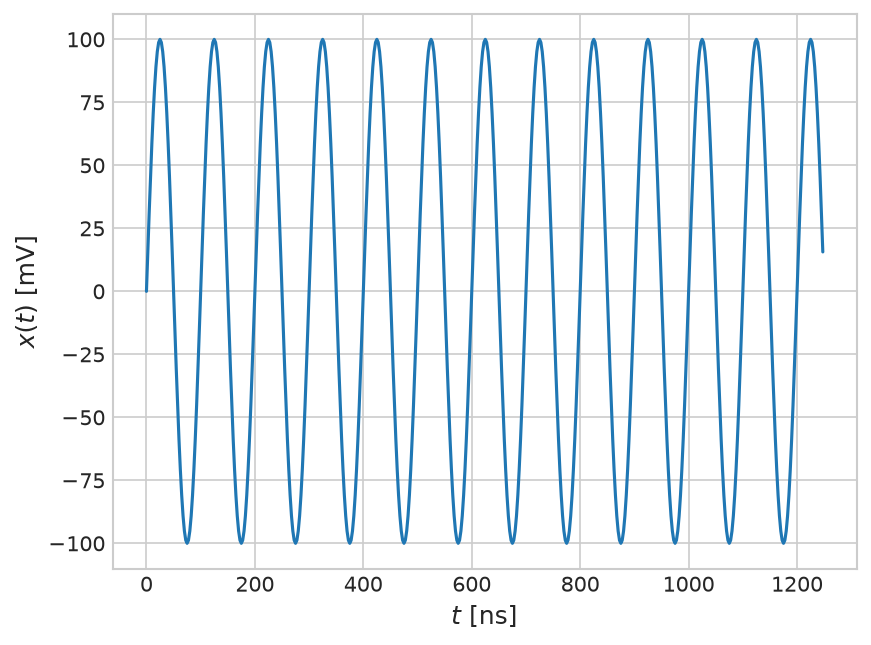

In [81]:
# Parameter
f0_hz = 10.0*1e6
n_periods = 100
samples_per_period = 40
amplitude = 0.1

# Generate base waveform
N_steps, dt = get_time_setup_from_frequency(f0_hz=f0_hz, n_periods=n_periods, samples_per_period=samples_per_period)
n_plot = N_steps // 8
t, x = sinusoidal_voltages(N_samples=N_steps, topology_parameter=lattice_topology,
                           amplitudes=[amplitude,0.0], frequencies=[f0_hz,0.0], time_step=dt)

# Display input signal
fig = plt.figure(dpi=150)
ax = fig.add_subplot()
_ = ax.plot(t[:n_plot]*1e9, x[:n_plot,0]*1000)
_ = ax.set_xlabel("$t~[\\mathrm{ns}]$", size='large')
_ = ax.set_ylabel("$x(t)~[\\mathrm{mV}]$", size='large')

### Run Simulation

In [82]:
# Run a dynamic simulation:
n_traj = 100
dyn_res = {
    'I0' : 10.0,
    'tau_0' : 1e-9,
    'R_max' : 25.0,
    'R_min' : 10.0
}
sim.run_dynamic_voltages(voltages=x, time_steps=t, target_electrode=1, n_trajectories=n_traj, verbose=True, dyn_res_kwargs=dyn_res)

# Get observables
p = sim.get_potential_storage()
i = sim.get_network_current_storage()
r = sim.get_resistance_storage()
y = sim.get_observable_storage()
y_e = sim.get_observable_error_storage()

### Data Analysis

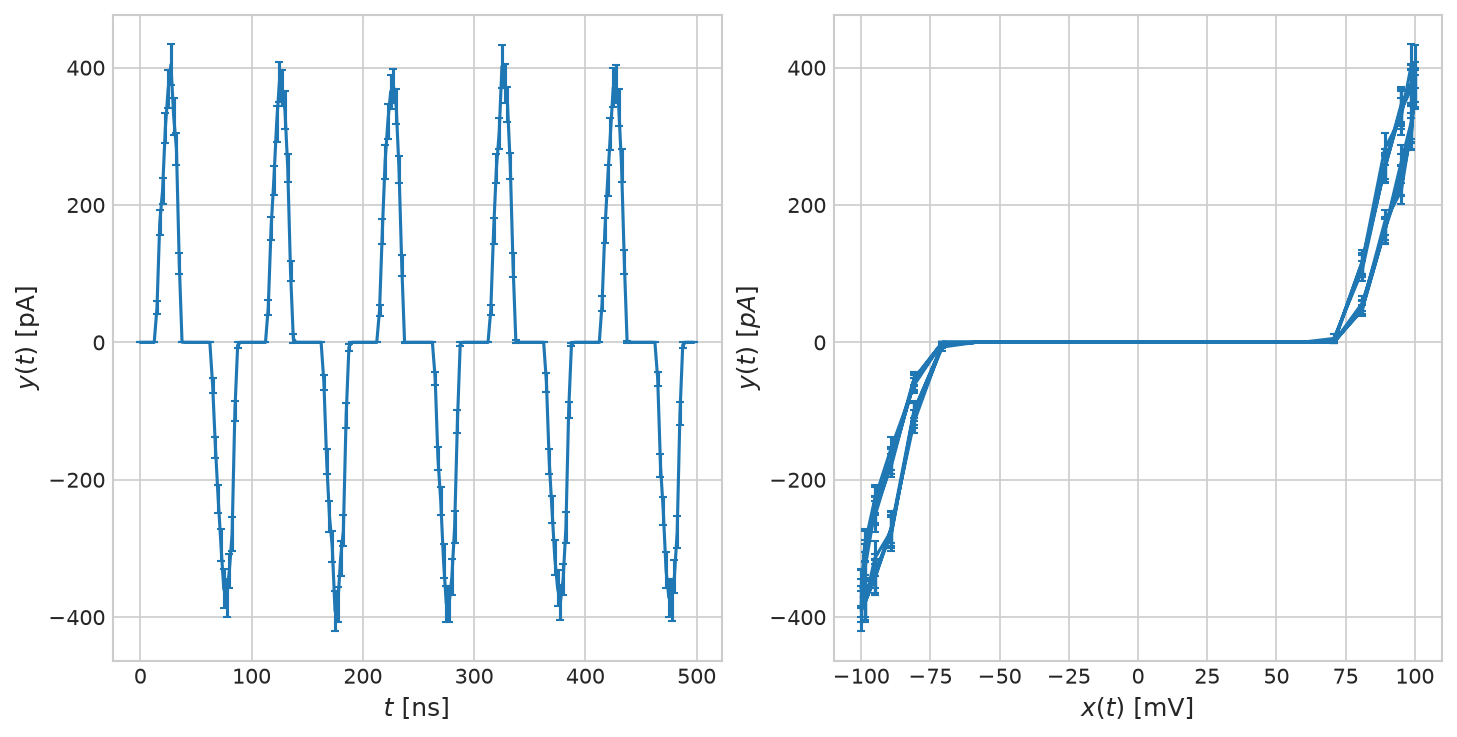

In [83]:
n_eq_periods = 80
n_plot_periods = 5
plot_range_1 = n_eq_periods*samples_per_period
plot_range_2 = (n_eq_periods+n_plot_periods)*samples_per_period

# Display input signal
fig = plt.figure(dpi=150, layout='constrained')
fig.set_figwidth(fig.get_figwidth()*1.5)

ax = fig.add_subplot(1,2,1)
_ = ax.errorbar(t[:n_plot_periods*samples_per_period]*1e9, y[plot_range_1:plot_range_2]*1e-6, y_e[plot_range_1:plot_range_2]*1e-6, capsize=2)
_ = ax.set_xlabel("$t~[\\mathrm{ns}]$", size='large')
_ = ax.set_ylabel("$y(t)~[\\mathrm{pA}]$", size='large')

ax = fig.add_subplot(1,2,2)
_ = ax.errorbar(x[plot_range_1:plot_range_2,0]*1000, y[plot_range_1:plot_range_2]*1e-6, y_e[plot_range_1:plot_range_2]*1e-6, capsize=2)
_ = ax.set_xlabel("$x(t)~[\\mathrm{mV}]$", size='large')
_ = ax.set_ylabel("$y(t)~[pA]$", size='large')

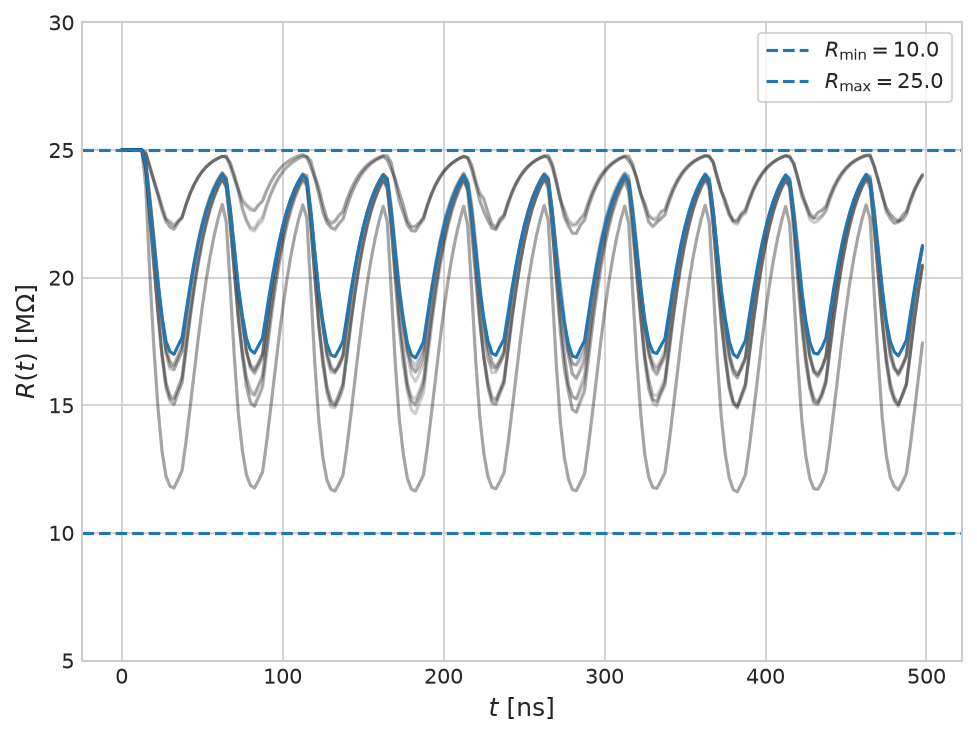

In [84]:
df_r = pd.DataFrame(r) 

fig = plt.figure(dpi=150, layout='constrained')
ax = fig.add_subplot()
_ = ax.plot(t[:n_plot_periods*samples_per_period]*1e9, df_r.values[:n_plot_periods*samples_per_period,:], alpha=0.1, color='black')
_ = ax.plot(t[:n_plot_periods*samples_per_period]*1e9, df_r.mean(axis=1)[:n_plot_periods*samples_per_period])

_ = ax.set_xlabel("$t~[\\mathrm{ns}]$", size='large')
_ = ax.set_ylabel("$R(t)~[\\mathrm{M\\Omega}]$", size='large')
_ = ax.axhline(dyn_res['R_min'], label=f'$R_\\mathrm{{min}} = {dyn_res['R_min']}$', ls='--')
_ = ax.axhline(dyn_res['R_max'], label=f'$R_\\mathrm{{max}} = {dyn_res['R_max']}$', ls='--')
_ = ax.set_ylim(5,30)
_ = ax.legend(frameon=True)